# Regression Notebook

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from plotnine import *
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Dataset

In [2]:
df = pd.read_csv("../data/regression.csv", header=0)
df = df.rename(columns={'RGDP(Billions)': 'RGDP'})
df['award_date'] = pd.to_datetime(df['award_date'])
print(df.shape)
df.head()

(157, 11)


,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,max_gfa,n_tenderers,award_date,accommodation_value
0,307976.156685,22.333632,114.186290,0.16,267.551886,1,ALS,227529.0,7.0,2010-03-11,9537.0
1,149438.202247,22.500946,114.145969,0.20,267.551886,1,ALS,385700.0,7.0,2010-05-24,3448.0
2,446122.168840,22.263681,114.180464,0.18,267.551886,1,govt-led,324862.0,7.0,2010-07-28,32014.0
3,674880.812334,22.311823,114.181960,0.19,267.551886,1,govt-led,869247.0,7.0,2010-08-06,12540.0
4,464839.094160,22.301907,114.187559,0.19,267.551886,1,ALS,365800.0,7.0,2010-08-17,9595.0


### Changing the Dependent Variable

In [62]:
df2 = df.copy() 

df2['log_adj_premium_per_sqm'] = np.log(df2['adj_premium_per_sqm'])
df2['log_RGDP'] = np.log(df2['RGDP'])
df2['log_max_gfa'] = np.log(df2['max_gfa'])
df2['log_accommodation_value'] = np.log(df2['accommodation_value'])

df2.head()

,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,max_gfa,n_tenderers,award_date,accommodation_value,log_adj_premium_per_sqm,log_RGDP,log_max_gfa,log_accommodation_value
0,307976.156685,22.333632,114.186290,0.16,267.551886,1,ALS,227529.0,7.0,2010-03-11,9537.0,12.637778,5.589314,12.335033,9.162934
1,149438.202247,22.500946,114.145969,0.20,267.551886,1,ALS,385700.0,7.0,2010-05-24,3448.0,11.914638,5.589314,12.862815,8.145550
2,446122.168840,22.263681,114.180464,0.18,267.551886,1,govt-led,324862.0,7.0,2010-07-28,32014.0,13.008348,5.589314,12.691156,10.373929
3,674880.812334,22.311823,114.181960,0.19,267.551886,1,govt-led,869247.0,7.0,2010-08-06,12540.0,13.422291,5.589314,13.675383,9.436679
4,464839.094160,22.301907,114.187559,0.19,267.551886,1,ALS,365800.0,7.0,2010-08-17,9595.0,13.049447,5.589314,12.809842,9.168997


## Split by Award Date

In [63]:
mask = df['award_date'].between("1999-04-01", "2013-02-01")

df_als = df[mask].copy()
df_gvnt = df[~mask].copy()

df_in_als = df[df['in_als'] == 1].drop(columns={'in_als'}).copy()
df_notin_als = df[df['in_als'] == 0].drop(columns={'in_als'}).copy()

In [64]:
df_als2 = df2[mask].copy()
df_gvnt2 = df2[~mask].copy()

df_in_als2 = df2[df2['in_als'] == 1].drop(columns={'in_als'}).copy()
df_notin_als2 = df2[df2['in_als'] == 0].drop(columns={'in_als'}).copy()

## EDA

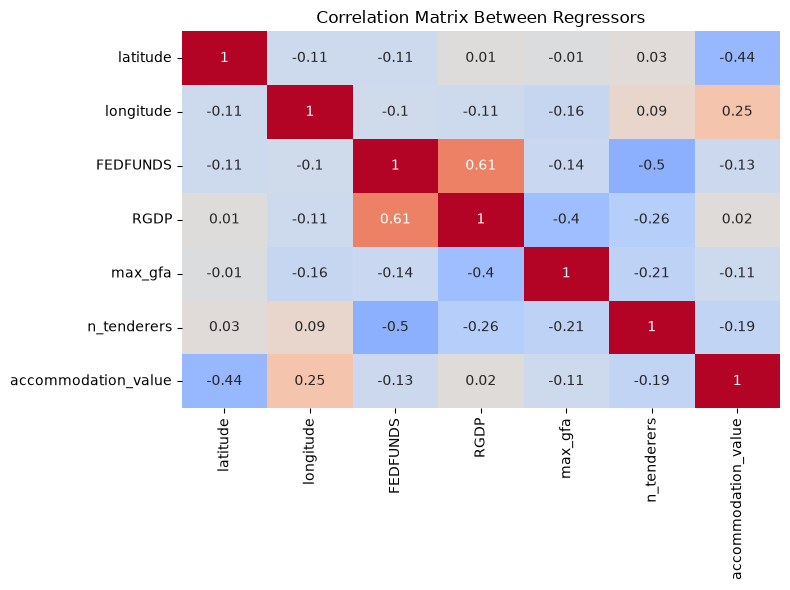

In [65]:
vars_corr = ['latitude','longitude','FEDFUNDS','RGDP','max_gfa','n_tenderers','accommodation_value']
corr = df[vars_corr].corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            cbar= False)
plt.title("Correlation Matrix Between Regressors")
plt.tight_layout()
plt.show()

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vars_corr.append('in_als')
X = df[vars_corr].copy()
X = sm.add_constant(X)
vif = pd.DataFrame()

vif['Variable'] = X.columns

vif['VIF'] = [variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,const,1.873246e+06
1,latitude,1.413540e+00
2,longitude,1.141835e+00
3,FEDFUNDS,2.637437e+00
4,RGDP,4.620808e+00
5,max_gfa,1.490946e+00
6,n_tenderers,1.850528e+00
7,accommodation_value,1.748440e+00
8,in_als,2.967872e+00


## Question 1: Did the determinants of government land-sale prices differ during the ALS period compared with the post-ALS period?

In [67]:
model1 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + in_als
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data=df_als
).fit()

print(model1.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.414
Model:                             OLS   Adj. R-squared:                  0.239
Method:                  Least Squares   F-statistic:                     2.358
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):             0.0377
Time:                         01:12:36   Log-Likelihood:                -543.27
No. Observations:                   40   AIC:                             1107.
Df Residuals:                       30   BIC:                             1123.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [68]:
model2 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + in_als
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data=df_gvnt
).fit()

print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.515
Model:                             OLS   Adj. R-squared:                  0.479
Method:                  Least Squares   F-statistic:                     14.35
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           4.39e-14
Time:                         01:12:36   Log-Likelihood:                -1588.5
No. Observations:                  117   AIC:                             3195.
Df Residuals:                      108   BIC:                             3220.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -9.4

In [69]:
model3 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + in_als
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df_als2
).fit()

print(model3.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.724
Model:                                 OLS   Adj. R-squared:                  0.642
Method:                      Least Squares   F-statistic:                     8.761
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           2.58e-06
Time:                             01:12:36   Log-Likelihood:                -35.024
No. Observations:                       40   AIC:                             90.05
Df Residuals:                           30   BIC:                             106.9
Df Model:                                9                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [70]:
model4 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + in_als
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df_gvnt2
).fit()

print(model4.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.648
Model:                                 OLS   Adj. R-squared:                  0.622
Method:                      Least Squares   F-statistic:                     24.81
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           2.82e-21
Time:                             01:12:36   Log-Likelihood:                -115.39
No. Observations:                      117   AIC:                             248.8
Df Residuals:                          108   BIC:                             273.6
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [71]:
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    float_format='%0.3f',
    model_names=['ALS Period', 'Post ALS', 'ALS Period (log)', 'Post ALS (log)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                          ALS Period       Post ALS     ALS Period (log) Post ALS (log)
---------------------------------------------------------------------------------------
Intercept               -51831620.855  -94672642.366*** -389.293*        -377.614***   
                        (61834510.700) (24831966.504)   (211.538)        (95.780)      
sale_regime[T.govt-led] -7232.872                       -0.233                         
                        (121614.383)                    (0.372)                        
latitude                -1506388.177** -638116.177**    -3.895**         0.224         
                        (623567.720)   (304192.880)     (1.769)          (1.014)       
longitude               755080.074     939842.553***    4.637**          3.312***      
                        (519932.996)   (209848.061)     (1.725)          (0.798)       
FEDFUNDS                -300350.530    -23703.049       -1.634           0.046         
                        (127896

In [72]:
# from stargazer.stargazer import Stargazer

# # 1. Arrange models in increasing order of terms (fewest on left, most on right)
# # Reorder this list if model4 has the most terms
# stargazer = Stargazer([model1, model2, model3, model4]) 

# stargazer.title("OLS Regression Results")
# stargazer.custom_columns(["ALS", "Post ALS", "Listed_ALS", 'Listed_ALS2'], [1,1,1,1])

# # 2. Force Intercept to the top, followed by your preferred variable order
# stargazer.covariate_order([
#     # Intercept
#     'Intercept',
    
#     # Macroeconomic Variables
#     'FEDFUNDS',
#     'RGDP',
    
#     # Spatial Variables
#     'latitude',
#     'longitude',
    
#     # Project & Market Characteristics
#     'max_gfa',
#     'accommodation_value',
#     'n_tenderers',
#     'sale_regime[T.govt-led]',
#     'in_als',
    
#     # log-terms
#     'log_RGDP',
#     'log_accommodation_value',
#     'log_max_gfa'
# ])


# print(stargazer.render_html())

#### What can be concluded thus far? 

1. Site development potential is consistently important
    - Approximately, a 1% increase in maximum GFA is associated with a 0.40% increase in adjusted premium per sqm. However, post-ALS, a 1% increase in maximum GFA is associated with a 0.25% increase in adjusted premium per sqm. 
    - This implies potentially that development potential mattered more during the ALS period. 

2. Accommodation value is consistently important

    - Approximately, a 1% increase in accommodation value is associated with a 0.44% increase in land premium during ALS, compared with a 0.90% increase after ALS.
    - The significance of the variable increased Post-ALS
    - This implies potentially that accomodation value mattered much more Post-ALS compared to during ALS 

        | Variable | ALS Period (log) | Post ALS (log) | 
        | :--- | :--- | :--- | 
        | `log_accommodation_value` | 0.442 ** | 0.904 *** | 
        | `log_max_gfa` | 0.401 *** | 0.252 *** | 

3. Macroeconomic Variables do not seem to explain much 

    - Both variables are not significant in either periods. 

        | Variable | ALS Period (log) | Post ALS (log) | 
        | :--- | :--- | :--- | 
        | `log_RGDP` | -8.839  | -0.621 | 
        | `FEDFUNDS` | -1.634 | 0.046 | 

4. Whether a land is listed in ALS does not significantly affect price in either period. 
    - Coefficient of `in_als` (Log Models)

        | Variable | ALS Period (log) | Post ALS (log) | 
        | :--- | :--- | :--- | 
        | `in_als` | 0.133  | 0.107 | 

- Variable is insignificant in both periods    

##### Finding: 
The determinants of land premiums appear to differ across the two periods

There are noticeable differences in the coefficients:

+ `log_max_gfa`: 0.401 → 0.252
+ `log_accommodation_value`: 0.442 → 0.904
+ `latitude`: -3.895 → 0.224
+ `longitude`: 4.637 → 3.312

## Question 2: Does ALS listing influence the determinants of land prices?

In [73]:
model5 = smf.ols(
"""
adj_premium_per_sqm ~
latitude
+ longitude
+ FEDFUNDS
+ sale_regime
+ RGDP
+ max_gfa
+ accommodation_value
+ n_tenderers
+ in_als : RGDP
+ in_als : max_gfa
+ in_als : accommodation_value
+ in_als : n_tenderers
""",
data=df
).fit()

print(model5.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.472
Model:                             OLS   Adj. R-squared:                  0.429
Method:                  Least Squares   F-statistic:                     10.75
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           5.04e-15
Time:                         01:12:36   Log-Likelihood:                -2134.9
No. Observations:                  157   AIC:                             4296.
Df Residuals:                      144   BIC:                             4336.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept 

In [74]:
model6 = smf.ols(
"""
adj_premium_per_sqm ~
latitude
+ longitude
+ FEDFUNDS
+ sale_regime
+ RGDP
+ max_gfa
+ accommodation_value
+ n_tenderers 
+ in_als : sale_regime
+ in_als : FEDFUNDS
+ in_als : sale_regime
+ in_als : RGDP
+ in_als : max_gfa
+ in_als : accommodation_value
+ in_als : n_tenderers 
""",
data=df
).fit()

print(model6.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.474
Model:                             OLS   Adj. R-squared:                  0.422
Method:                  Least Squares   F-statistic:                     9.144
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           4.52e-14
Time:                         01:12:36   Log-Likelihood:                -2134.7
No. Observations:                  157   AIC:                             4299.
Df Residuals:                      142   BIC:                             4345.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

In [75]:
model7 = smf.ols(
"""
log_adj_premium_per_sqm ~
latitude
+ longitude
+ FEDFUNDS
+ sale_regime
+ log_RGDP
+ log_max_gfa
+ log_accommodation_value
+ n_tenderers
+ in_als: n_tenderers
+ in_als : log_RGDP
+ in_als : log_max_gfa
+ in_als : log_accommodation_value
""",
data=df2
).fit()

print(model7.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.631
Model:                                 OLS   Adj. R-squared:                  0.600
Method:                      Least Squares   F-statistic:                     20.51
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           1.41e-25
Time:                             01:12:36   Log-Likelihood:                -158.98
No. Observations:                      157   AIC:                             344.0
Df Residuals:                          144   BIC:                             383.7
Df Model:                               12                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [76]:
model8 = smf.ols(
"""
log_adj_premium_per_sqm ~
latitude
+ longitude
+ FEDFUNDS
+ sale_regime
+ log_RGDP
+ log_max_gfa
+ log_accommodation_value
+ n_tenderers 
+ in_als : sale_regime
+ in_als : FEDFUNDS
+ in_als : sale_regime
+ in_als : log_RGDP
+ in_als : log_max_gfa
+ in_als : log_accommodation_value
+ in_als : n_tenderers 
""",
data=df2
).fit()

print(model8.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.646
Model:                                 OLS   Adj. R-squared:                  0.612
Method:                      Least Squares   F-statistic:                     18.55
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           1.58e-25
Time:                             01:12:36   Log-Likelihood:                -155.60
No. Observations:                      157   AIC:                             341.2
Df Residuals:                          142   BIC:                             387.1
Df Model:                               14                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [77]:
table = summary_col(
    [model5, model6, model7, model8],
    stars=True,
    float_format='%0.3f',
    model_names=['Comp 1', 'Comp 2', 'Comp 1 (log)', 'Comp 2 (log)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                                     Comp 1           Comp 2      Comp 1 (log) Comp 2 (log)
-------------------------------------------------------------------------------------------
Intercept                      -100003953.199*** -65671801.457*** -372.390***  -248.288*** 
                               (22280400.855)    (15093444.482)   (81.455)     (54.753)    
sale_regime[T.govt-led]        -86133.993        -33286869.570*** -0.256       -109.625*** 
                               (83262.092)       (7477714.146)    (0.287)      (28.956)    
latitude                       -696764.501**     -692480.677**    -0.678       -0.577      
                               (272290.962)      (274294.423)     (0.893)      (0.881)     
longitude                      996336.512***     984851.909***    3.319***     3.284***    
                               (188359.417)      (190859.823)     (0.696)      (0.688)     
FEDFUNDS                       -20172.376        -21751.251       0.036        

In [78]:
# from stargazer.stargazer import Stargazer

# # 1. Arrange models in increasing order of terms (fewest on left, most on right)
# # Reorder this list if model4 has the most terms
# stargazer = Stargazer([model5, model6, model7, model8]) 

# stargazer.title("OLS Regression Results")
# stargazer.custom_columns(['Comp 1', 'Comp 2', 'Comp 1 (log)', 'Comp 2 (log)'], [1,1,1,1])

# # 2. Force Intercept to the top, followed by your preferred variable order
# stargazer.covariate_order([
#     # Constant
#     'Intercept',

#     # Policy variables
#     'sale_regime[T.govt-led]',

#     # Macroeconomic variables
#     'FEDFUNDS',
#     'log_RGDP',

#     # Spatial variables
#     'latitude',
#     'longitude',

#     # Site characteristics
#     'log_max_gfa',
#     'log_accommodation_value',

#     # Competition
#     'n_tenderers',

#     # Interaction terms
#     'in_als:sale_regime[ALS]',
#     'in_als:sale_regime[govt-led]', 
#     'in_als:FEDFUNDS',
#     'in_als:log_RGDP',
#     'in_als:log_max_gfa',
#     'in_als:log_accommodation_value',
#     'in_als:n_tenderers'
# ])


# print(stargazer.render_html())

In [79]:
pd.crosstab(df['in_als'], df['sale_regime'])

sale_regime,ALS,govt-led
in_als,,
0,0,101
1,9,47


#### What can be concluded thus far? 

1. Inconclusive on whether developmental potential differed by ALS

    | Variable | Non-ALS Effect | ALS Interaction | Implied ALS Effect | 
    | :--- | :--- | :--- | :--- | 
    | `log_max_gfa` | 0.289*** | -0.048 | 0.241 | 
    | `log_accommodation_value` | 0.871*** | -0.197 | 0.674 | 

    - The interaction terms are not statistically significant
        + We cannot conclude that ALS significantly changes the effect of `max_gfa` or `accommodation_value`.

2. The effect of `n_tenderers` is significant when land premium is not log

    | Variable | Non-ALS Effect | ALS Interaction | Implied ALS Effect | 
    | :--- | :--- | :--- | :--- | 
    | `n_tenderers` | 1636.176 | -19257.719*** | -17621.543 | 

    - Since `n_tenderers` are a measure of competition, competition seem to significant for sites that were listed in ALS

3. Spatial characteristics remain important 

    | Variable | Comp 1 | Comp 2 | Comp 1 (log) | Comp 2 (log) |
    | :--- | :--- | :--- | :--- | :--- |
    | `latitude` | -696764.501** | -692480.677** | -0.678 | -0.577 | 
    | `longitude` | 996336.512*** | 984851.909*** | 3.319*** | 3.284*** | 

    - Longitudinal distribution of land is consistently significant

4. Interaction Term `in_als : sale_regime` 

    - The only significant coefficient is `in_als:sale_regime[ALS]`. 
        + However, this might be misleading because there are only 9 land in entire sample that was sold under the ALS `sale_regime`

5. Macroeconomic Variables remain insignificant


##### Finding: 

There are no significant conclusion from this set of regressions. 

In [80]:
model9 = smf.ols(
    """
    adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data= df_in_als
).fit()

print(model9.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.441
Model:                             OLS   Adj. R-squared:                  0.346
Method:                  Least Squares   F-statistic:                     4.635
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           0.000321
Time:                         01:12:36   Log-Likelihood:                -758.36
No. Observations:                   56   AIC:                             1535.
Df Residuals:                       47   BIC:                             1553.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [81]:
model10 = smf.ols(
    """
    adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data= df_notin_als
).fit()

print(model10.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.503
Model:                             OLS   Adj. R-squared:                  0.466
Method:                  Least Squares   F-statistic:                     13.46
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           6.79e-12
Time:                         01:12:36   Log-Likelihood:                -1374.2
No. Observations:                  101   AIC:                             2764.
Df Residuals:                       93   BIC:                             2785.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.2

In [82]:
model11 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df_in_als2
).fit()

print(model11.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.619
Model:                                 OLS   Adj. R-squared:                  0.555
Method:                      Least Squares   F-statistic:                     9.563
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           9.77e-08
Time:                             01:12:36   Log-Likelihood:                -56.267
No. Observations:                       56   AIC:                             130.5
Df Residuals:                           47   BIC:                             148.8
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [83]:
model12 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df_notin_als2
).fit()

print(model12.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.681
Model:                                 OLS   Adj. R-squared:                  0.657
Method:                      Least Squares   F-statistic:                     28.41
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           1.53e-20
Time:                             01:12:36   Log-Likelihood:                -95.889
No. Observations:                      101   AIC:                             207.8
Df Residuals:                           93   BIC:                             228.7
Df Model:                                7                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [84]:
table = summary_col(
    [model9, model10, model11, model12],
    stars=True,
    float_format='%0.3f',
    model_names=['In ALS', 'Not in ALS', 'In ALS (log)', 'Not in ALS (log)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                            In ALS         Not in ALS    In ALS (log) Not in ALS (log)
--------------------------------------------------------------------------------------
Intercept               -40089710.819  -124225363.974*** -211.463     -438.163***     
                        (40236151.886) (27119749.943)    (153.011)    (93.035)        
sale_regime[T.govt-led] -29061.609                       -0.302                       
                        (94880.117)                      (0.343)                      
latitude                -1189619.502** -468337.309       -3.259**     0.737           
                        (473785.998)   (333856.183)      (1.606)      (1.025)         
longitude               578273.033*    1162320.030***    2.281*       3.744***        
                        (335020.730)   (230560.068)      (1.257)      (0.801)         
FEDFUNDS                107057.153     -17447.712        0.849        0.075           
                        (190558.643)   (21

In [85]:
# from stargazer.stargazer import Stargazer

# # 1. Arrange models in increasing order of terms (fewest on left, most on right)
# # Reorder this list if model4 has the most terms
# stargazer = Stargazer([model9, model10, model11, model12]) 

# stargazer.title("OLS Regression Results")
# stargazer.custom_columns(['In ALS', 'Not in ALS', 'In ALS (log)', 'Not in ALS (log)'], [1,1,1,1])

# # 2. Force Intercept to the top, followed by your preferred variable order
# stargazer.covariate_order([
#     # Intercept
#     'Intercept',
    
#     # Macroeconomic Variables
#     'FEDFUNDS',
#     'RGDP',
    
#     # Spatial Variables
#     'latitude',
#     'longitude',
    
#     # Project & Market Characteristics
#     'max_gfa',
#     'accommodation_value',
#     'n_tenderers',
#     'sale_regime[T.govt-led]',
    
#     # log-terms
#     'log_RGDP',
#     'log_accommodation_value',
#     'log_max_gfa'
# ])


# print(stargazer.render_html())

#### What can be concluded thus far? 

1. Macroeconomic Variables are largely insignificant
   
    | Variable | In ALS | Not in ALS | In ALS (log) | Not in ALS (log) |
    | :--- | :--- | :--- | :--- | :--- |
    | `FEDFUNDS` | 107057.153 | -17447.712 | 0.849 | 0.075 | 
    | `RGDP` | 	4036.016 | 6938.420*** | - | - |
    | `log_RGDP` | - | - | 4.843 | -0.743 |

    - Only `RGDP` became significant to explaining land premium (level) for land not in ALS

2. Spatial Features show the same relationship as previous regressions

    | Variable | In ALS | Not in ALS | In ALS (log) | Not in ALS (log) |
    | :--- | :--- | :--- | :--- | :--- |
    | `latitude` | -1189619.502** | -692480.677** | -0.678 | -0.577 | 
    | `longitude` | 578273.033* | 1162320.030*** | 2.281* | 3.744*** | 

    - Longitudinal distribution remain significant
    - Latitdudinal distribution loses its significance for land not in ALS

3. `n_tenderers` is only significant in explaining land premium in for land listed in ALS

    | Variable | In ALS | Not in ALS | In ALS (log) | Not in ALS (log) |
    | :--- | :--- | :--- | :--- | :--- |
    | `n_tenderers` | -14685.245** | 2093.552 | -0.005 | -0.009 |

    - Similar to previous set of regression, competition measures seem more relevant to land listed under ALS

4. Development Potential is important

    | Variable | In ALS | Not in ALS | In ALS (log) | Not in ALS (log) |
    | :--- | :--- | :--- | :--- | :--- | 
    | `max_gfa` | 0.054 | 0.345** | - | - | 
    | `accommodation_value` | 2.679 | 10.617*** | - | - | 
    | `log_max_gfa` | - | - | 0.305*** | 0.276*** |
    | `log_accommodation_value` | - | - | 0.620*** | 0.910*** |

    - Development potential is not significant only for explaining land premium in ALS

##### Finding: 
The determinants of land premiums appear to be similar to the determinants when land are split by sale periods

| Variable | In ALS | Not in ALS | In ALS (log) | Not in ALS (log) |
| :--- | :--- | :--- | :--- | :--- | 
| `latitude` | -1189619.502** | -692480.677** | -0.678 | -0.577 | 
| `longitude` | 578273.033* | 1162320.030*** | 2.281* | 3.744*** | 
| `max_gfa` | 0.054 | 0.345** | - | - | 
| `accommodation_value` | 2.679 | 10.617*** | - | - | 
| `log_max_gfa` | - | - | 0.305*** | 0.276*** |
| `log_accommodation_value` | - | - | 0.620*** | 0.910*** |


## Question 3: Does determinants of land premium change between ALS Listing and Sale Period? 

| | During ALS Period | Post-ALS Period | 
| :--- | :--- | :--- | 
| In ALS | Group 1 | Group 2 | 
| Not in ALS | Group 3 | Group 4 | 

In [86]:
group1a = df[(df['award_date'].between("1999-04-01", "2013-02-01")) & (df['in_als'] == 1)].drop(columns={'award_date', 'in_als'}).copy()
group1b = df2[(df2['award_date'].between("1999-04-01", "2013-02-01")) & (df2['in_als'] == 1)].drop(columns={'award_date', 'in_als'}).copy()

group2a = df[(~df['award_date'].between("1999-04-01", "2013-02-01")) & (df['in_als'] == 1)].drop(columns={'award_date', 'in_als'}).copy()
group2b = df2[(~df2['award_date'].between("1999-04-01", "2013-02-01")) & (df2['in_als'] == 1)].drop(columns={'award_date', 'in_als'}).copy()

group3a = df[(df['award_date'].between("1999-04-01", "2013-02-01")) & (df['in_als'] == 0)].drop(columns={'award_date', 'in_als'}).copy()
group3b = df2[(df2['award_date'].between("1999-04-01", "2013-02-01")) & (df2['in_als'] == 0)].drop(columns={'award_date', 'in_als'}).copy()

group4a = df[(~df['award_date'].between("1999-04-01", "2013-02-01")) & (df['in_als'] == 0)].drop(columns={'award_date', 'in_als'}).copy()
group4b = df2[(~df2['award_date'].between("1999-04-01", "2013-02-01")) & (df2['in_als'] == 0)].drop(columns={'award_date', 'in_als'}).copy()

In [87]:
print(group1a.shape)
print(group1b.shape)

print(group2a.shape)
print(group2b.shape)

print(group3a.shape)
print(group3b.shape)

print(group4a.shape)
print(group4b.shape)

(39, 9)
(39, 13)
(17, 9)
(17, 13)
(1, 9)
(1, 13)
(100, 9)
(100, 13)


- Can't build the regression because of a lack of samples
- Can only build regression for Group 1 and 4

In [88]:
model13 = smf.ols(
    """
    adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data=group1a
).fit()

print(model13.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.408
Model:                             OLS   Adj. R-squared:                  0.250
Method:                  Least Squares   F-statistic:                     2.587
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):             0.0281
Time:                         01:12:36   Log-Likelihood:                -530.18
No. Observations:                   39   AIC:                             1078.
Df Residuals:                       30   BIC:                             1093.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [89]:
model14 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=group1b
).fit()

print(model14.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.724
Model:                                 OLS   Adj. R-squared:                  0.650
Method:                      Least Squares   F-statistic:                     9.831
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           1.38e-06
Time:                             01:12:36   Log-Likelihood:                -34.642
No. Observations:                       39   AIC:                             87.28
Df Residuals:                           30   BIC:                             102.3
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [90]:
model15 = smf.ols(
    """
    adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data=group4a
).fit()

print(model15.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.530
Model:                             OLS   Adj. R-squared:                  0.495
Method:                  Least Squares   F-statistic:                     14.85
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           8.05e-13
Time:                         01:12:36   Log-Likelihood:                -1358.1
No. Observations:                  100   AIC:                             2732.
Df Residuals:                       92   BIC:                             2753.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.0

In [91]:
model16 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=group4b
).fit()

print(model16.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.681
Model:                                 OLS   Adj. R-squared:                  0.657
Method:                      Least Squares   F-statistic:                     28.09
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           2.68e-20
Time:                             01:12:36   Log-Likelihood:                -95.402
No. Observations:                      100   AIC:                             206.8
Df Residuals:                           92   BIC:                             227.6
Df Model:                                7                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [92]:
table = summary_col(
    [model13, model14, model15, model16],
    stars=True,
    float_format='%0.3f',
    model_names=['Group 1a', 'Group 1b', 'Group 4a', 'Group4b'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                           Group 1a     Group 1b      Group 4a       Group4b  
------------------------------------------------------------------------------
Intercept               -51692144.635  -389.161* -109139925.500*** -447.201***
                        (61875172.096) (211.755) (27196945.155)    (100.048)  
sale_regime[T.govt-led] -7232.872      -0.233                                 
                        (121614.383)   (0.372)                                
latitude                -1506388.177** -3.895**  -561875.761*      0.781      
                        (623567.720)   (1.769)   (328023.561)      (1.045)    
longitude               755080.074     4.637**   1050615.606***    3.802***   
                        (519932.996)   (1.725)   (229711.784)      (0.837)    
FEDFUNDS                -300350.530    -1.634    -16200.090        0.075      
                        (1278969.525)  (3.950)   (21414.876)       (0.071)    
RGDP                    -918.717                 60

In [93]:
# from stargazer.stargazer import Stargazer

# # 1. Arrange models in increasing order of terms (fewest on left, most on right)
# # Reorder this list if model4 has the most terms
# stargazer = Stargazer([model13, model14, model15, model16]) 

# stargazer.title("OLS Regression Results")
# stargazer.custom_columns(['Group 1a', 'Group 1b', 'Group 4a', 'Group4b'], [1,1,1,1])

# # 2. Force Intercept to the top, followed by your preferred variable order
# stargazer.covariate_order([
#     # Intercept
#     'Intercept',
    
#     # Macroeconomic Variables
#     'FEDFUNDS',
#     'RGDP',
    
#     # Spatial Variables
#     'latitude',
#     'longitude',
    
#     # Project & Market Characteristics
#     'max_gfa',
#     'accommodation_value',
#     'n_tenderers',
#     'sale_regime[T.govt-led]',
    
#     # log-terms
#     'log_RGDP',
#     'log_accommodation_value',
#     'log_max_gfa'
# ])


# print(stargazer.render_html())

#### What can be concluded thus far? 

1. Group 1a regression is not useful. 
    + While the model is significant, the only significant regressor is latitude. 

2. Log Models are mode informative. They paint a consistent story. 

    + Longitude remains consistently significant as a regressor. 
    + Latitude is not a significant regressor Post-ALS
    + Development potential as measured by `log_accommodation_value` and `log_max_gfa` are significant in explaining log land premium 
    + RGDP becomes a significant regressor to land premium (level) Post-ALS

    | Variable | Group 1b | Group 4b | Group 4a | 
    | :--- | :--- | :--- | :--- | 
    | `latitude` | -3.895** | 0.781 | -561875.761* | 
    | `longitude` | 4.637** | 3.802*** | 1050615.606*** | 
    | `log_accommodation_value` | 0.442** | 0.908*** | - | 
    | `log_max_gfa` | 0.401*** | 0.270*** | - | 
    | `RGDP` | - | - | 6026.273*** | 

##### Finding: 

- Nothing significantly different from above.

## Question 4: What if I build a model with all regressors, Log and Non-Log?

In [94]:
model17 = smf.ols(
    """
    adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    + in_als
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data = df2
).fit()

print(model17.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.552
Model:                             OLS   Adj. R-squared:                  0.515
Method:                  Least Squares   F-statistic:                     14.78
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           8.51e-20
Time:                         01:12:36   Log-Likelihood:                -2122.1
No. Observations:                  157   AIC:                             4270.
Df Residuals:                      144   BIC:                             4310.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [95]:
model18 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    + in_als
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data = df2
).fit()

print(model18.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.640
Model:                                 OLS   Adj. R-squared:                  0.610
Method:                      Least Squares   F-statistic:                     21.34
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           2.48e-26
Time:                             01:12:36   Log-Likelihood:                -157.02
No. Observations:                      157   AIC:                             340.0
Df Residuals:                          144   BIC:                             379.8
Df Model:                               12                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [96]:
table = summary_col(
    [model17, model18],
    stars=True,
    float_format='%0.3f',
    model_names=['adj_premium_per_sqm', 'log_adj_premium_per_sqm'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                        adj_premium_per_sqm log_adj_premium_per_sqm
-------------------------------------------------------------------
Intercept               -60413520.931       -492.636**             
                        (52072061.032)      (190.904)              
sale_regime[T.govt-led] -107961.049         -0.390                 
                        (84677.309)         (0.310)                
latitude                -812765.840***      -1.195                 
                        (252449.962)        (0.926)                
longitude               433956.016**        3.075***               
                        (199392.992)        (0.731)                
FEDFUNDS                -20745.632          0.005                  
                        (19460.897)         (0.071)                
RGDP                    -13539.406          -0.106                 
                        (32427.013)         (0.119)                
max_gfa                 -0.033              0.0

## Question 5: Is the resumption of Land Auctions in 2011 a more significant event?

In [97]:
baseline_als = model3
baseline_gvnt = model4

df3_als = df2[df2['award_date'].between("2004-01-01", "2011-04-01")].drop(columns={'award_date'}).copy()
df3_auction = df2[~df2['award_date'].between("2004-01-01", "2011-04-01")].drop(columns = ('award_date')).copy()

# df3_als = df2[df2['award_date'] < "2011-04-01"].drop(columns={'award_date'}).copy()
# df3_auction = df2[df2['award_date'] > "2011-04-01"].drop(columns = ('award_date')).copy()

In [98]:
print(df3_als.shape)
print(df3_auction.shape)

(10, 14)
(147, 14)


In [99]:
model21 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + in_als
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data= df3_als
).fit()

print(model21.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.793
Model:                             OLS   Adj. R-squared:                  0.380
Method:                  Least Squares   F-statistic:                     1.920
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):              0.317
Time:                         01:12:36   Log-Likelihood:                -127.71
No. Observations:                   10   AIC:                             269.4
Df Residuals:                        3   BIC:                             271.5
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [100]:
model22 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + in_als
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df3_als
).fit()

print(model22.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.895
Model:                                 OLS   Adj. R-squared:                  0.686
Method:                      Least Squares   F-statistic:                     4.278
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):              0.130
Time:                             01:12:37   Log-Likelihood:                 2.5073
No. Observations:                       10   AIC:                             8.985
Df Residuals:                            3   BIC:                             11.10
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [101]:
model23 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + FEDFUNDS
    + sale_regime
    + in_als
    + RGDP
    + max_gfa
    + accommodation_value
    + n_tenderers
    """,
    data= df3_auction
).fit()

print(model23.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.443
Model:                             OLS   Adj. R-squared:                  0.407
Method:                  Least Squares   F-statistic:                     12.12
Date:                 Wed, 12 Aug 2026   Prob (F-statistic):           6.01e-14
Time:                         01:12:37   Log-Likelihood:                -2004.7
No. Observations:                  147   AIC:                             4029.
Df Residuals:                      137   BIC:                             4059.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

In [102]:
model24 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + in_als
    + sale_regime
    + n_tenderers
    + log_RGDP
    + log_max_gfa
    + log_accommodation_value
    """,
    data=df3_auction
).fit()

print(model24.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.618
Model:                                 OLS   Adj. R-squared:                  0.593
Method:                      Least Squares   F-statistic:                     24.67
Date:                     Wed, 12 Aug 2026   Prob (F-statistic):           1.07e-24
Time:                             01:12:37   Log-Likelihood:                -153.28
No. Observations:                      147   AIC:                             326.6
Df Residuals:                          137   BIC:                             356.5
Df Model:                                9                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [103]:
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [model21, model22, model23, model24],
    stars=True,
    float_format='%0.3f',
    model_names=['ALS Period', 'ALS Period (log)' ,'Land Auction', 'Land Auction(log)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                          ALS Period  ALS Period (log)   Land Auction   Land Auction(log)
-----------------------------------------------------------------------------------------
Intercept               -2819.290     -6.608           -94926358.515*** -374.981***      
                        (2574.347)    (3.939)          (23288541.634)   (84.429)         
sale_regime[T.govt-led] 18375.640     0.085            -45599.648       -0.144           
                        (154339.116)  (0.287)          (153992.733)     (0.526)          
latitude                -1756609.675  -6.168           -786169.291***   -0.901           
                        (1588534.145) (4.163)          (289141.857)     (0.949)          
longitude               2107203.054   6.078            970893.837***    3.332***         
                        (1448565.833) (3.366)          (196452.339)     (0.720)          
FEDFUNDS                5899518.515   16.505           -36177.478*      0.010            
         

#### What can be concluded thus far? 

1. There are not enough observations for a robust regression to be done in ALS period. 

2. Similar story being formed. 

    + `Longitude`, `log_accommodation_value` and `log_max_gfa` are significant in explaining log land premium 

    | Variable | Land Auction (log) |
    | :--- | :--- |
    | `longitude` | 3.332*** | 
    | `log_max_gfa` | 0.261*** |
    | `log_accommodation_value` | 0.772*** |

##### Finding: 

- Nothing significantly different from above.

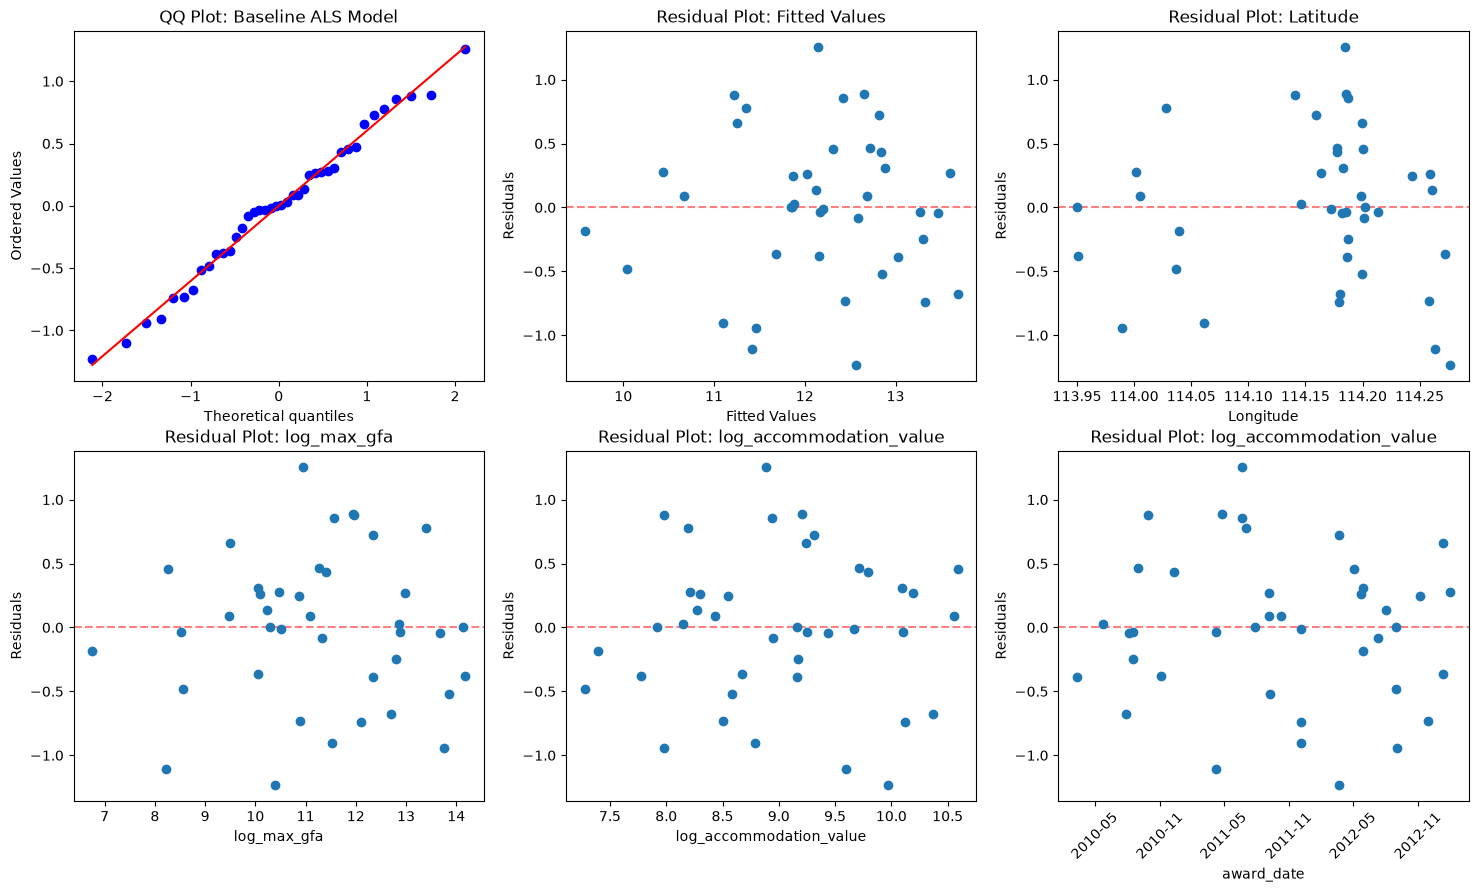

In [107]:
import scipy.stats as stats
fig, axes = plt.subplots(nrows=2, ncols=3, figsize = (18,10))

ax1 = axes[0, 0]
stats.probplot(baseline_als.resid, dist = "norm", plot=ax1)
ax1.set_title("QQ Plot: Baseline ALS Model")

ax2 = axes[0, 1]
ax2.scatter(baseline_als.fittedvalues, baseline_als.resid, zorder = 3)
ax2.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax2.set(xlabel = "Fitted Values", ylabel= "Residuals", title= "Residual Plot: Fitted Values")

ax3 = axes[0, 2]
ax3.scatter(df_als2['longitude'], baseline_als.resid, zorder = 3)
ax3.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax3.set(xlabel = "Longitude", ylabel= "Residuals", title= "Residual Plot: Latitude")

ax4 = axes[1, 0]
ax4.scatter(df_als2['log_max_gfa'], baseline_als.resid, zorder = 3)
ax4.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax4.set(xlabel = "log_max_gfa", ylabel = "Residuals", title= "Residual Plot: log_max_gfa")

ax5 = axes[1, 1]
ax5.scatter(df_als2['log_accommodation_value'], baseline_als.resid, zorder = 3)
ax5.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax5.set(xlabel = "log_accommodation_value", ylabel = "Residuals", title= "Residual Plot: log_accommodation_value")

ax6 = axes[1, 2]
ax6.scatter(df_als2['award_date'], baseline_als.resid, zorder = 3)
ax6.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax6.tick_params(axis = 'x', rotation = 45)
ax6.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax6.set(xlabel = "award_date", ylabel = "Residuals", title= "Residual Plot: log_accommodation_value")

plt.show()

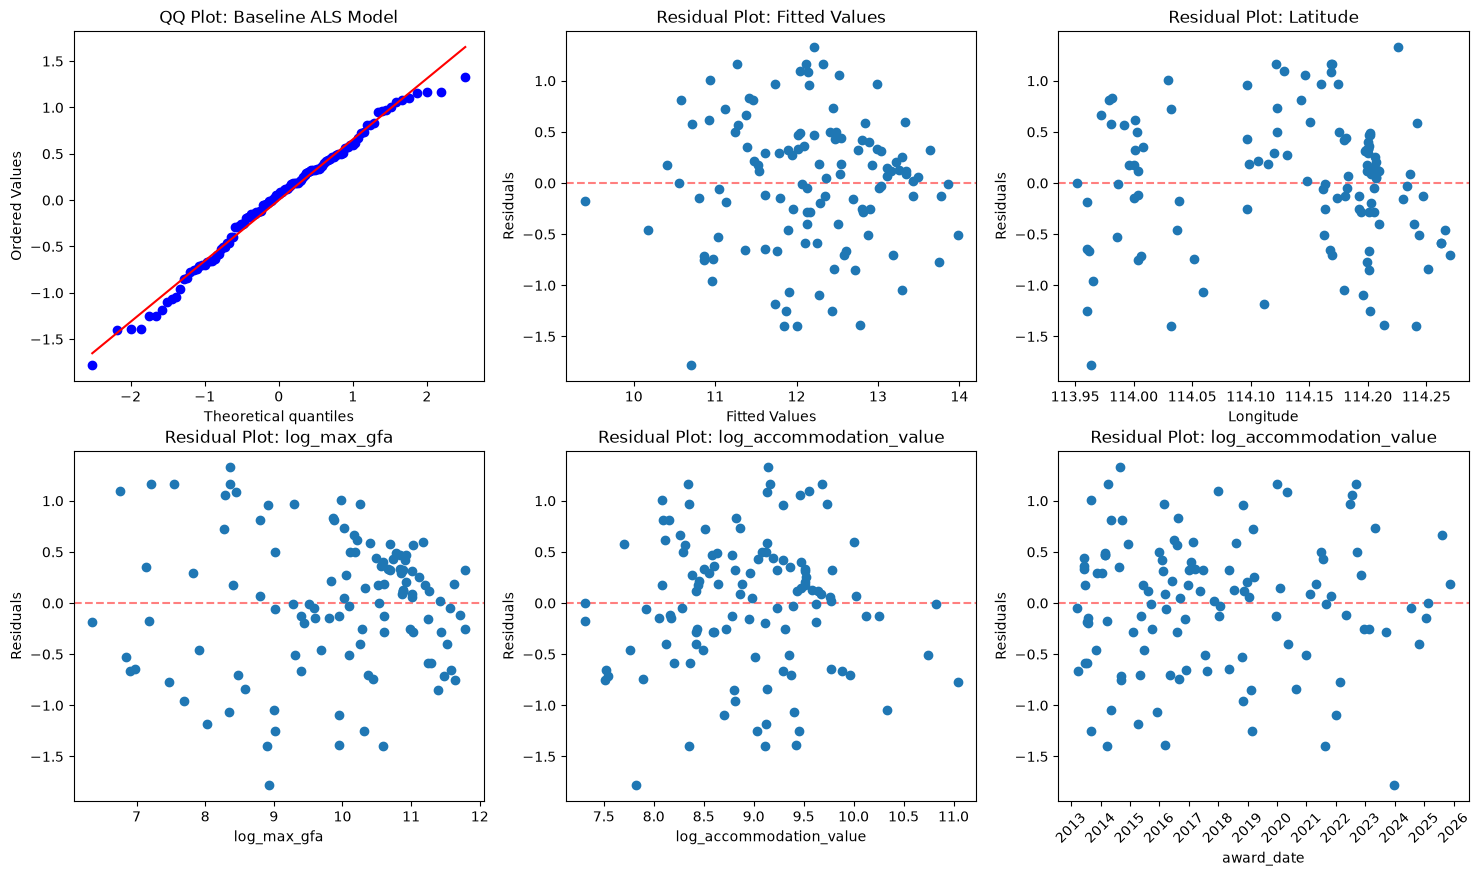

In [109]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize = (18,10))

ax1 = axes[0, 0]
stats.probplot(baseline_gvnt.resid, dist = "norm", plot=ax1)
ax1.set_title("QQ Plot: Baseline ALS Model")

ax2 = axes[0, 1]
ax2.scatter(baseline_gvnt.fittedvalues, baseline_gvnt.resid, zorder = 3)
ax2.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax2.set(xlabel = "Fitted Values", ylabel= "Residuals", title= "Residual Plot: Fitted Values")

ax3 = axes[0, 2]
ax3.scatter(df_gvnt2['longitude'], baseline_gvnt.resid, zorder = 3)
ax3.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax3.set(xlabel = "Longitude", ylabel= "Residuals", title= "Residual Plot: Latitude")

ax4 = axes[1, 0]
ax4.scatter(df_gvnt2['log_max_gfa'], baseline_gvnt.resid, zorder = 3)
ax4.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax4.set(xlabel = "log_max_gfa", ylabel = "Residuals", title= "Residual Plot: log_max_gfa")

ax5 = axes[1, 1]
ax5.scatter(df_gvnt2['log_accommodation_value'], baseline_gvnt.resid, zorder = 3)
ax5.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax5.set(xlabel = "log_accommodation_value", ylabel = "Residuals", title= "Residual Plot: log_accommodation_value")

ax6 = axes[1, 2]
ax6.scatter(df_gvnt2['award_date'], baseline_gvnt.resid, zorder = 3)
ax6.axhline(y=0, color = "red", alpha = 0.5, linestyle = "--", zorder = 0)
ax6.tick_params(axis = 'x', rotation = 45)
ax6.xaxis.set_major_locator(mdates.YearLocator(1))
ax6.set(xlabel = "award_date", ylabel = "Residuals", title= "Residual Plot: log_accommodation_value")

plt.show()